In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 23

### Загрузка и подготовка данных

In [9]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, roc_auc_score, ConfusionMatrixDisplay)

url_train = "/Users/denis/Desktop/VS code projects/Safe Driver Prediction/porto-seguro-safe-driver-prediction/train.csv"
df_train = pd.read_csv(url_train)
print(f'Размер: {df_train.shape}')
print(f'{df_train.columns}')
df_train.head()

Размер: (595212, 59)
Index(['id', 'target', 'ps_ind_01', 'ps_ind_02_cat', 'ps_ind_03',
       'ps_ind_04_cat', 'ps_ind_05_cat', 'ps_ind_06_bin', 'ps_ind_07_bin',
       'ps_ind_08_bin', 'ps_ind_09_bin', 'ps_ind_10_bin', 'ps_ind_11_bin',
       'ps_ind_12_bin', 'ps_ind_13_bin', 'ps_ind_14', 'ps_ind_15',
       'ps_ind_16_bin', 'ps_ind_17_bin', 'ps_ind_18_bin', 'ps_reg_01',
       'ps_reg_02', 'ps_reg_03', 'ps_car_01_cat', 'ps_car_02_cat',
       'ps_car_03_cat', 'ps_car_04_cat', 'ps_car_05_cat', 'ps_car_06_cat',
       'ps_car_07_cat', 'ps_car_08_cat', 'ps_car_09_cat', 'ps_car_10_cat',
       'ps_car_11_cat', 'ps_car_11', 'ps_car_12', 'ps_car_13', 'ps_car_14',
       'ps_car_15', 'ps_calc_01', 'ps_calc_02', 'ps_calc_03', 'ps_calc_04',
       'ps_calc_05', 'ps_calc_06', 'ps_calc_07', 'ps_calc_08', 'ps_calc_09',
       'ps_calc_10', 'ps_calc_11', 'ps_calc_12', 'ps_calc_13', 'ps_calc_14',
       'ps_calc_15_bin', 'ps_calc_16_bin', 'ps_calc_17_bin', 'ps_calc_18_bin',
       'ps_calc_19_bin'

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,...,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,...,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,...,4,2,7,7,0,1,1,0,1,0
3,16,0,0,1,2,0,0,1,0,0,...,2,2,4,9,0,0,0,0,0,0
4,17,0,0,2,0,1,0,1,0,0,...,3,1,1,3,0,0,0,1,1,0


In [10]:
df_train.filter(like='bin').describe()

,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
count,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000
mean,0.393742,0.257033,0.163921,0.185304,0.000373,0.001692,0.009439,0.000948,0.660823,0.121081,0.153446,0.122427,0.627840,0.554182,0.287182,0.349024,0.153318
std,0.488579,0.436998,0.370205,0.388544,0.019309,0.041097,0.096693,0.030768,0.473430,0.326222,0.360417,0.327779,0.483381,0.497056,0.452447,0.476662,0.360295
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
df_train.filter(like='cat').describe()

,ps_ind_02_cat,ps_ind_04_cat,ps_ind_05_cat,ps_car_01_cat,ps_car_02_cat,ps_car_03_cat,ps_car_04_cat,ps_car_05_cat,ps_car_06_cat,ps_car_07_cat,ps_car_08_cat,ps_car_09_cat,ps_car_10_cat,ps_car_11_cat
count,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000
mean,1.358943,0.416794,0.405188,8.295933,0.829931,-0.504899,0.725192,-0.157732,6.555340,0.910027,0.832080,1.328890,0.992136,62.215674
std,0.664594,0.493311,1.350642,2.508270,0.375716,0.788654,2.153463,0.844417,5.501445,0.347106,0.373796,0.978747,0.091619,33.012455
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000,1.000000
25%,1.000000,0.000000,0.000000,7.000000,1.000000,-1.000000,0.000000,-1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,32.000000
50%,1.000000,0.000000,0.000000,7.000000,1.000000,-1.000000,0.000000,0.000000,7.000000,1.000000,1.000000,2.000000,1.000000,65.000000
75%,2.000000,1.000000,0.000000,11.000000,1.000000,0.000000,0.000000,1.000000,11.000000,1.000000,1.000000,2.000000,1.000000,93.000000
max,4.000000,1.000000,6.000000,11.000000,1.000000,1.000000,9.000000,1.000000,17.000000,1.000000,1.000000,4.000000,2.000000,104.000000


In [12]:
df_train.loc[:, ~df_train.columns.str.contains('cat|bin', case=False)].describe()

,id,target,ps_ind_01,ps_ind_03,ps_ind_14,ps_ind_15,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_11,...,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14
count,5.952120e+05,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,...,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000
mean,7.438036e+05,0.036448,1.900378,4.423318,0.012451,7.299922,0.610991,0.439184,0.551102,2.346072,...,1.885886,7.689445,3.005823,9.225904,2.339034,8.433590,5.441382,1.441918,2.872288,7.539026
std,4.293678e+05,0.187401,1.983789,2.699902,0.127545,3.546042,0.287643,0.404264,0.793506,0.832548,...,1.134927,1.334312,1.414564,1.459672,1.246949,2.904597,2.332871,1.202963,1.694887,2.746652
min,7.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,...,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.719915e+05,0.000000,0.000000,2.000000,0.000000,5.000000,0.400000,0.200000,0.525000,2.000000,...,1.000000,7.000000,2.000000,8.000000,1.000000,6.000000,4.000000,1.000000,2.000000,6.000000
50%,7.435475e+05,0.000000,1.000000,4.000000,0.000000,7.000000,0.700000,0.300000,0.720677,3.000000,...,2.000000,8.000000,3.000000,9.000000,2.000000,8.000000,5.000000,1.000000,3.000000,7.000000
75%,1.115549e+06,0.000000,3.000000,6.000000,0.000000,10.000000,0.900000,0.600000,1.000000,3.000000,...,3.000000,9.000000,4.000000,10.000000,3.000000,10.000000,7.000000,2.000000,4.000000,9.000000
max,1.488027e+06,1.000000,7.000000,11.000000,4.000000,13.000000,0.900000,1.800000,4.037945,3.000000,...,6.000000,10.000000,9.000000,12.000000,7.000000,25.000000,19.000000,10.000000,13.000000,23.000000


Класс 0 - 573518 элементов
Класс 1 - 21694 элементов


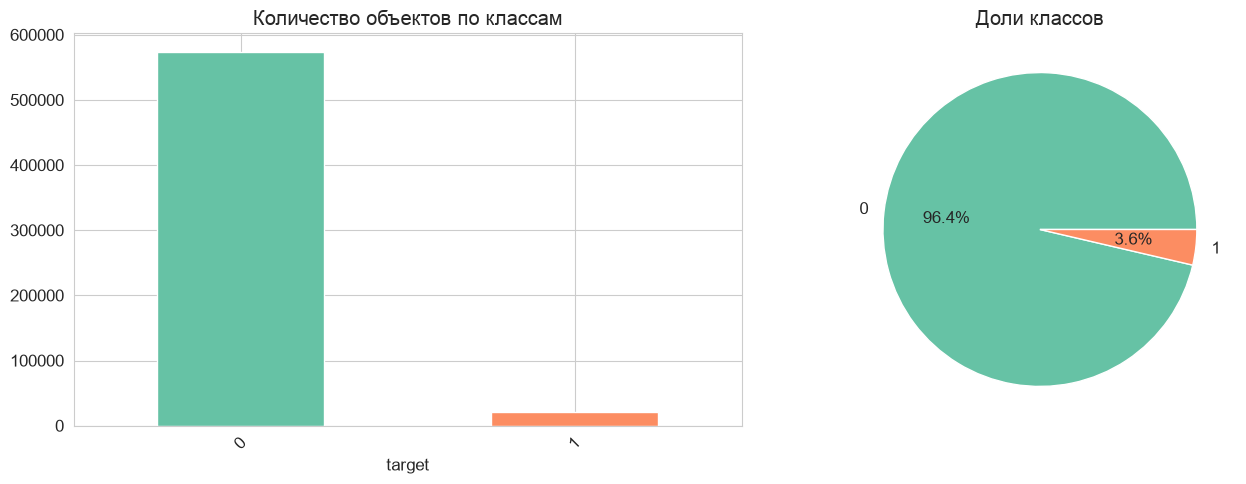

In [13]:
target_col = 'target'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


print(f"Класс 0 - {(df_train[target_col] == 0).sum()} элементов")
print(f"Класс 1 - {(df_train[target_col] == 1).sum()} элементов")
df_train[target_col].value_counts().plot.bar(ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Количество объектов по классам')
axes[0].tick_params(axis='x', rotation=45)

df_train[target_col].value_counts(normalize=True).plot.pie(ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_ylabel('')
axes[1].set_title('Доли классов')
plt.tight_layout()
plt.show()

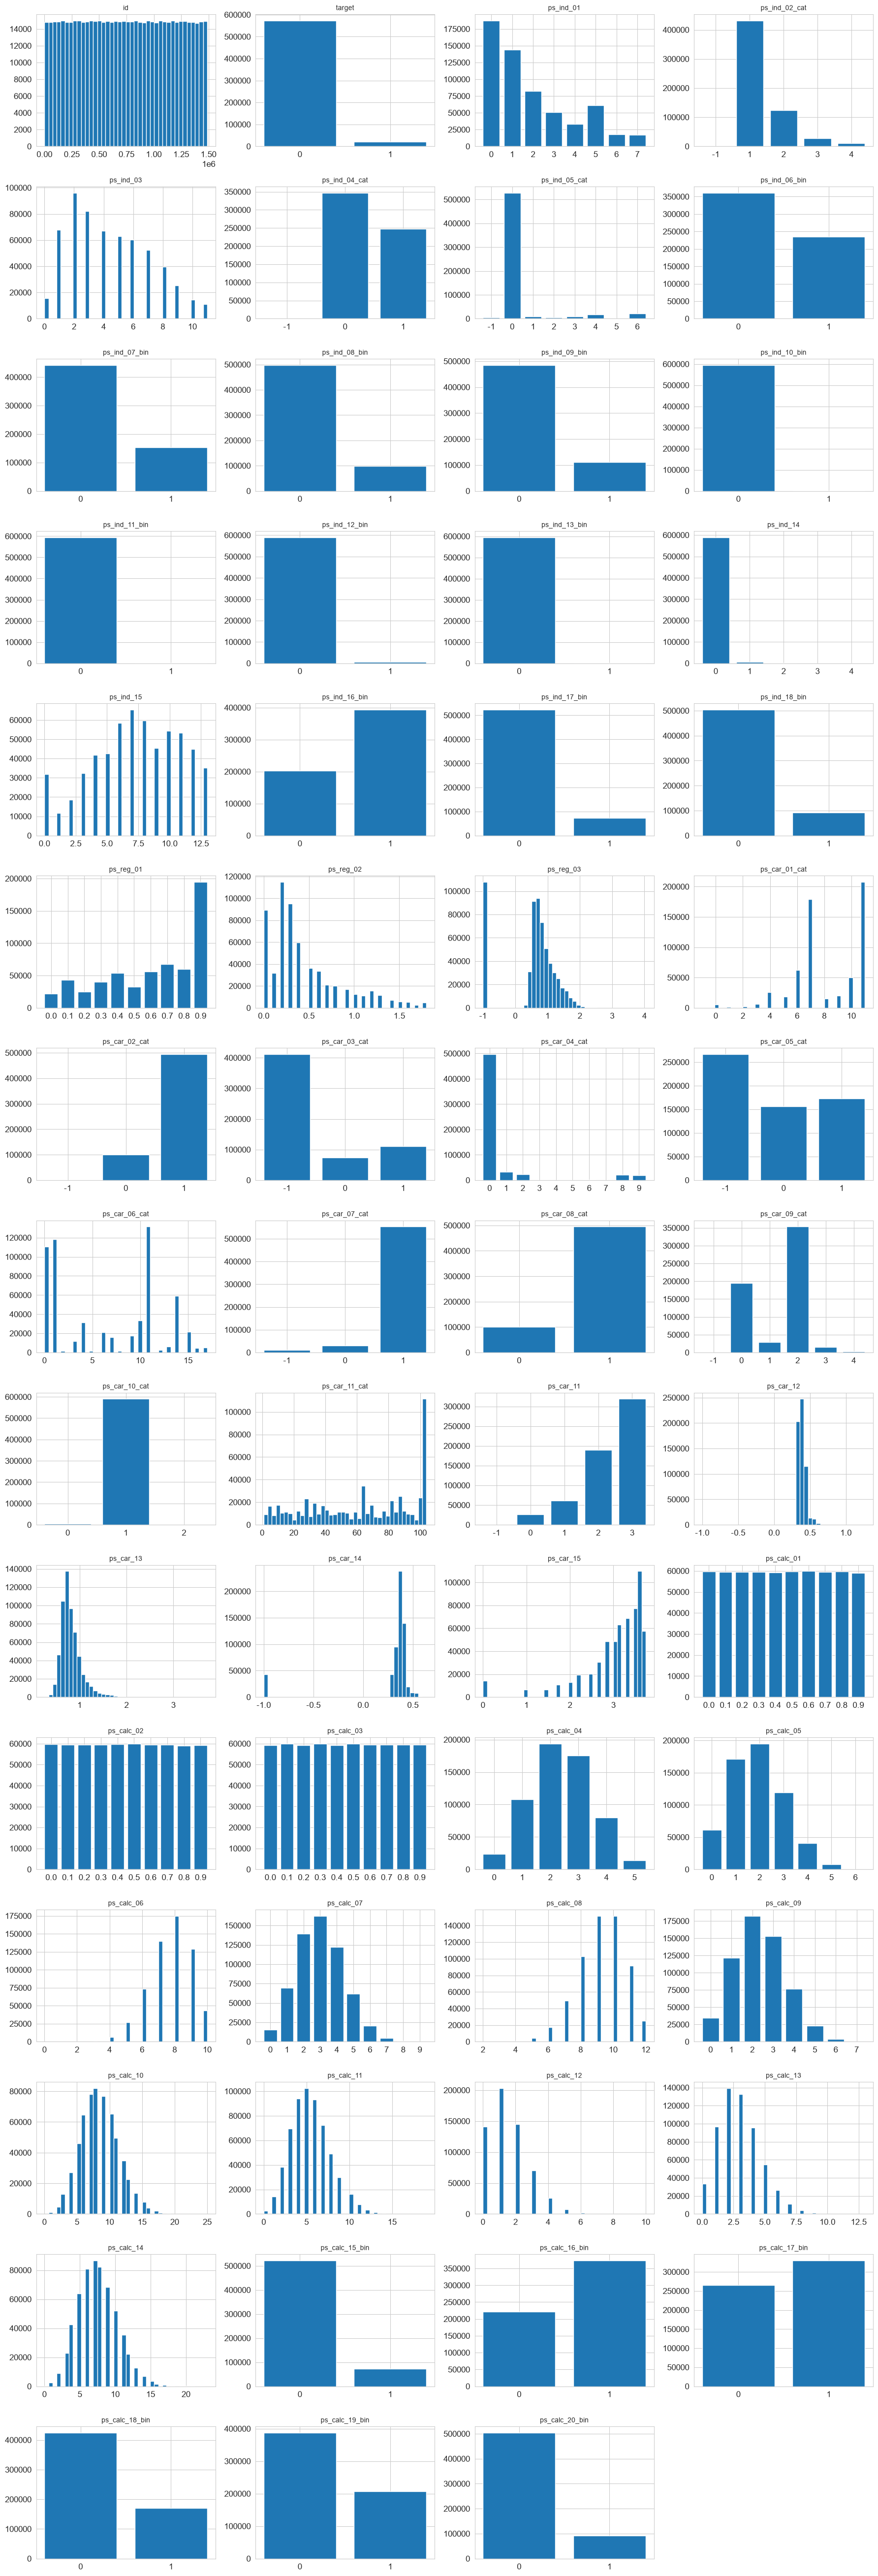

In [14]:
cols = df_train.columns.tolist()

n_plot_cols = 4
n_rows = (len(cols) + n_plot_cols - 1) // n_plot_cols

fig, axes = plt.subplots(
    n_rows,
    n_plot_cols,
    figsize=(18, n_rows * 3.5)
)

axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, cols):
    n_unique = df_train[col].nunique()

    if pd.api.types.is_numeric_dtype(df_train[col]) and n_unique > 10:
        ax.hist(
            df_train[col].dropna(),
            bins=40
        )
    else:
        counts = df_train[col].value_counts(dropna=False).sort_index()

        ax.bar(
            counts.index.astype(str),
            counts.values
        )


    ax.set_title(col, fontsize=10)

for ax in axes[len(cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

Уберём лишние признаки

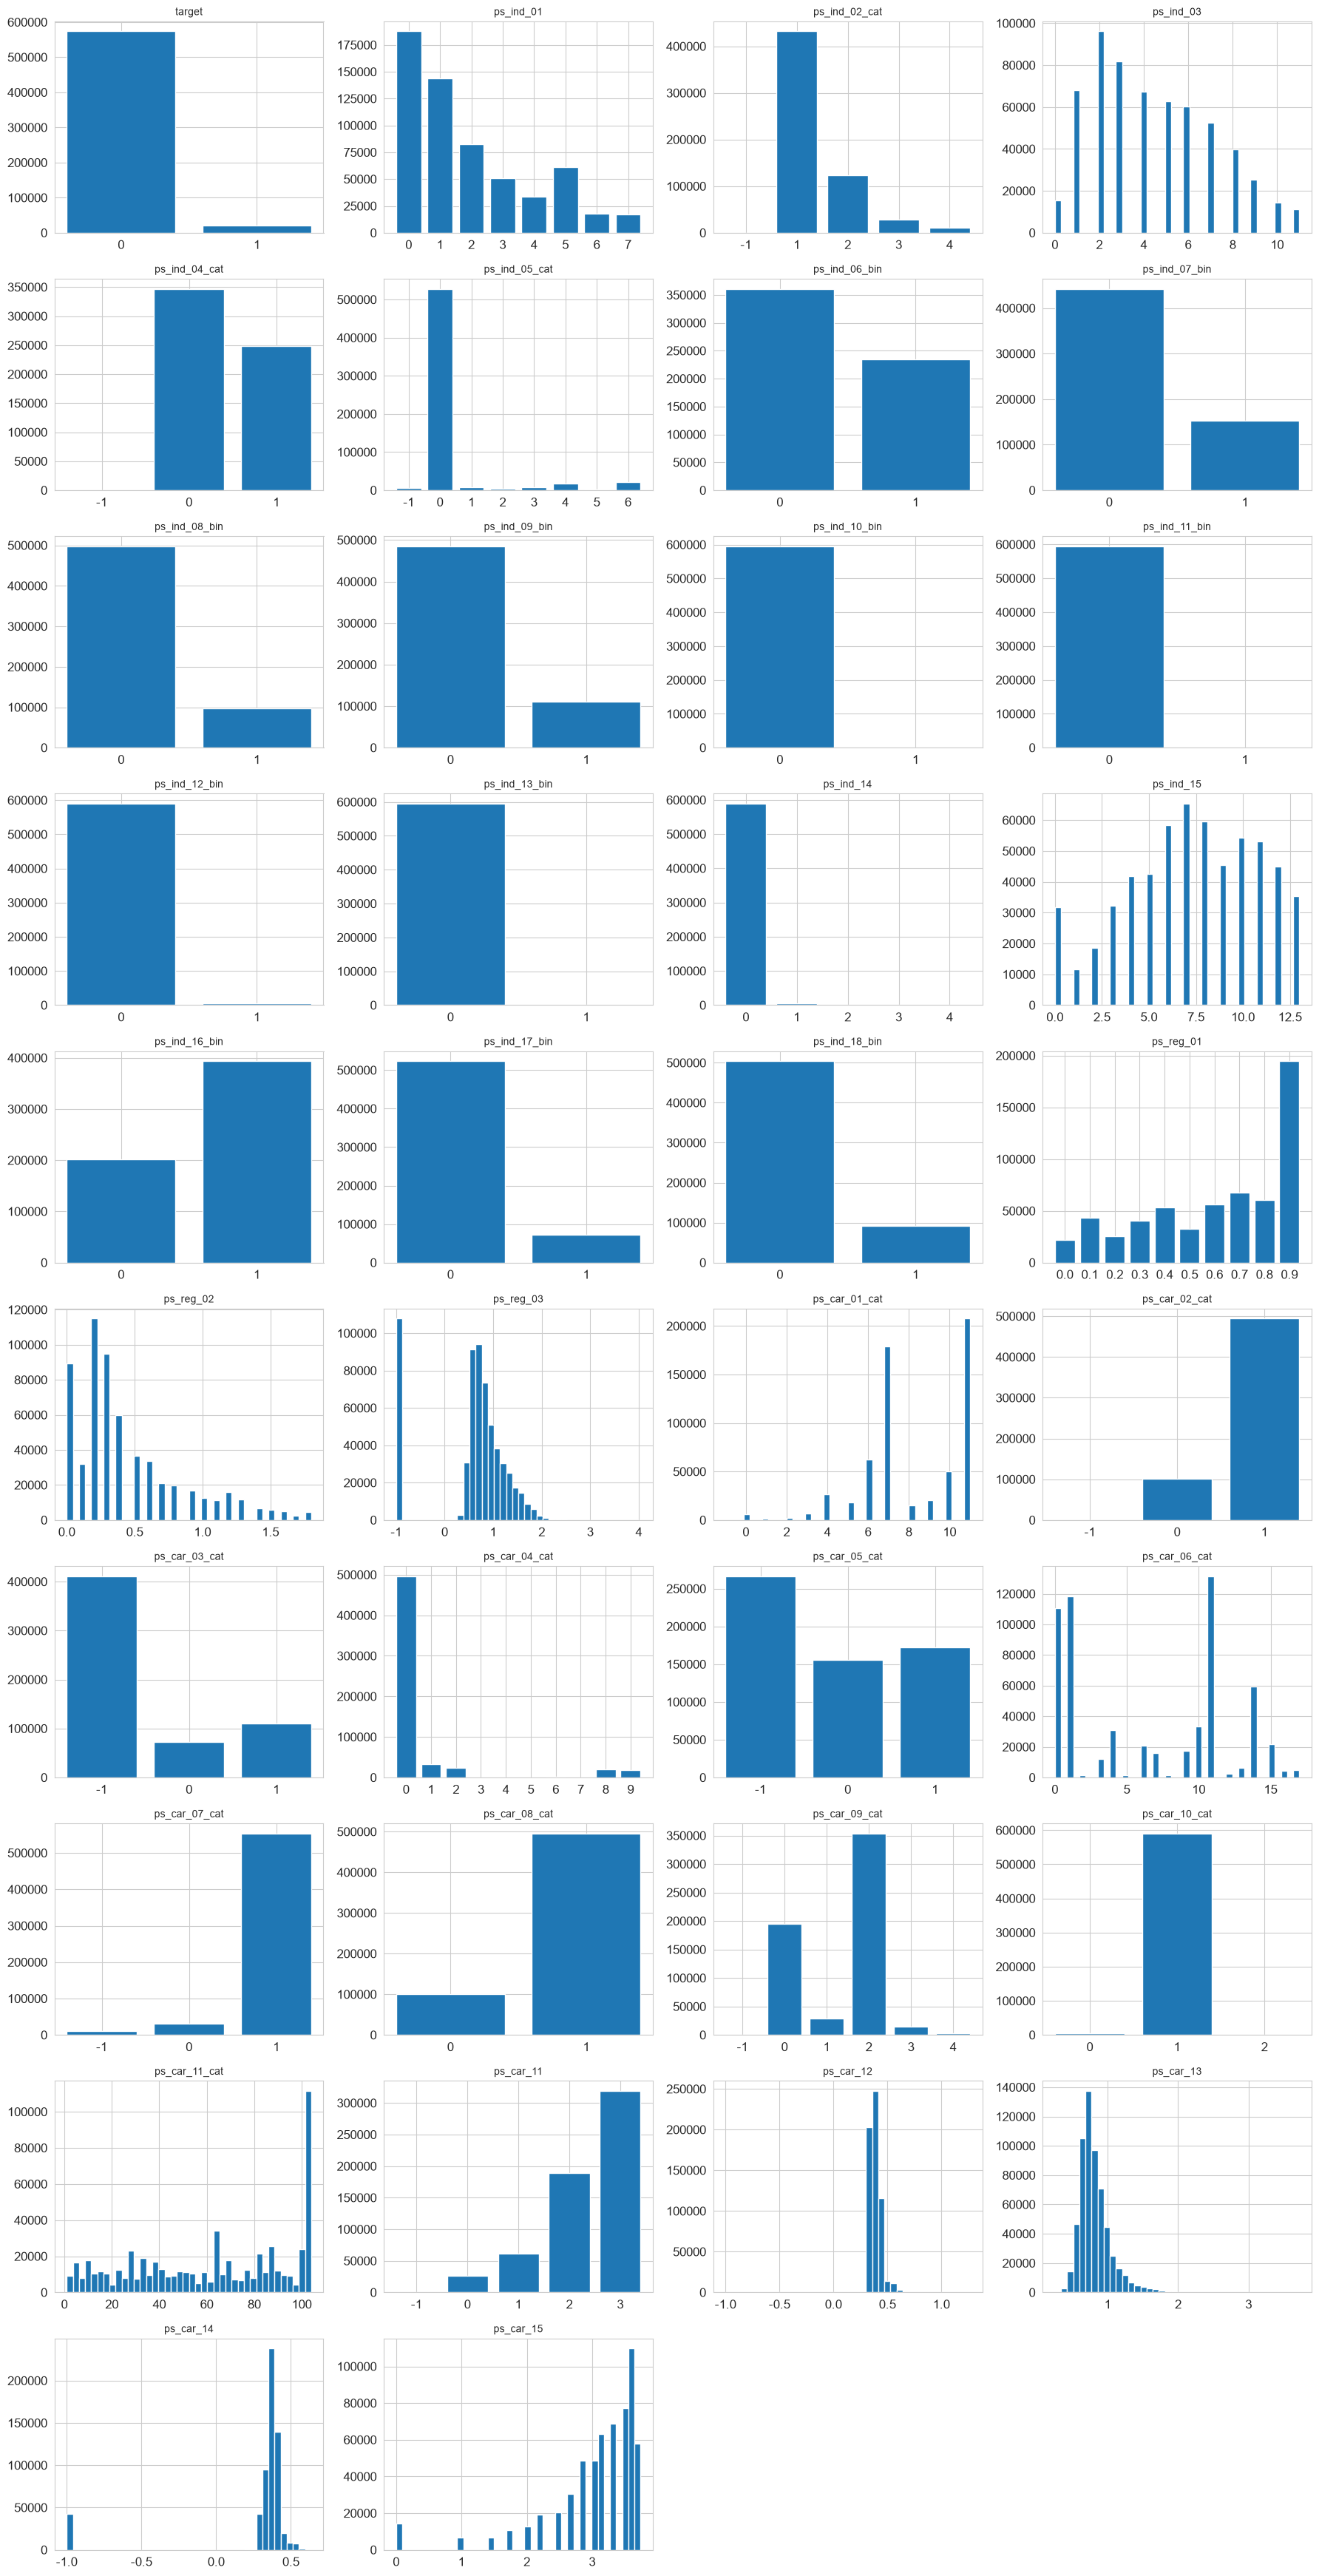

In [15]:
drop_col = ["id"]
df_tr_cl = df_train.loc[:, ~df_train.columns.str.contains('ps_calc_*')].drop(columns=drop_col)
cols = df_tr_cl.columns.tolist()

n_plot_cols = 4
n_rows = (len(cols) + n_plot_cols - 1) // n_plot_cols

fig, axes = plt.subplots(
    n_rows,
    n_plot_cols,
    figsize=(18, n_rows * 3.5)
)

axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, cols):
    n_unique = df_tr_cl[col].nunique()

    if pd.api.types.is_numeric_dtype(df_tr_cl[col]) and n_unique > 10:
        ax.hist(
            df_tr_cl[col].dropna(),
            bins=40
        )
    else:
        counts = df_tr_cl[col].value_counts(dropna=False).sort_index()

        ax.bar(
            counts.index.astype(str),
            counts.values
        )


    ax.set_title(col, fontsize=10)

for ax in axes[len(cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

Уберём выбросы на ps_car_14, ps_car_12, ps_reg_03

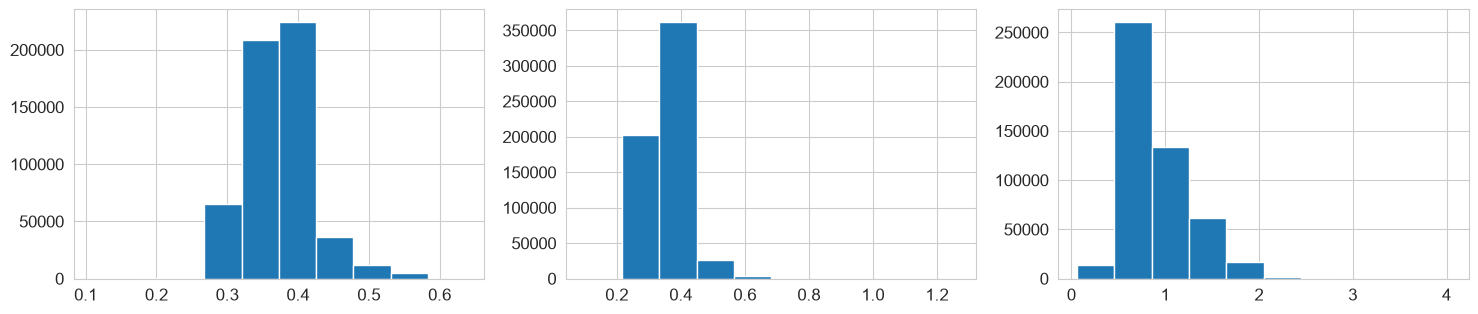

In [16]:
outlier_cols = ["ps_car_14", "ps_car_12", "ps_reg_03"]

df_tr_cl[outlier_cols] = df_tr_cl[outlier_cols].replace(-1, np.nan)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 3.5))
axes[0].hist(df_tr_cl[["ps_car_14"]])
ax.set_title("ps_car_14", fontsize=10)
axes[1].hist(df_tr_cl[["ps_car_12"]])
ax.set_title("ps_car_12", fontsize=10)
axes[2].hist(df_tr_cl[["ps_reg_03"]])
ax.set_title("ps_reg_03", fontsize=10)
plt.show()

### Feature Engineering
Созданы шесть новых признаков:

- `ps_car_12_div_ps_car_11`, `ps_car_12_div_ps_car_13`,
  `ps_car_12_div_ps_car_14`, `ps_car_12_div_ps_car_15` —
  отношения `ps_car_12` к остальным четырём числовым признакам
  группы `ps_car`. Они проверяют, полезно ли модели относительное
  значение характеристик вместо их значений по отдельности.
- `missing_count` — число исходных признаков со значением `-1`
  у объекта. Здесь `-1` рассматривается как пропуск.
- `ind_bin_sum` — число активных (`= 1`) бинарных признаков
  группы `ps_ind`.

Для отношений при пропуске в числителе, пропуске в знаменателе
или нулевом знаменателе результат равен `NaN`. LightGBM может
работать с такими значениями.

Признаки анонимизированы, поэтому пользу отношений нужно проверить
по Gini. Особенно осторожно следует трактовать отношение с
`ps_car_11`: сначала стоит изучить его уникальные значения и
убрать это отношение, если столбец фактически является кодом категории.

In [ ]:
base_cols = [
    col for col in df_tr_cl.columns
    if col not in ("id", "target")
]

missing = (
    df_tr_cl[base_cols].eq(-1)
    | df_tr_cl[base_cols].isna()
)
df_tr_cl["missing_count"] = missing.sum(axis=1)

ind_bin_cols = [
    col for col in base_cols
    if col.startswith("ps_ind_") and col.endswith("_bin")
]
df_tr_cl["ind_bin_sum"] = df_tr_cl[ind_bin_cols].eq(1).sum(axis=1)

new_features = [
    "missing_count",
    "ind_bin_sum",
]

df_tr_cl[new_features].head()

,missing_count,ind_bin_sum
0,1,2
1,2,2
2,3,2
3,0,2
4,2,2


In [18]:
cat_cols = [
    col for col in df_tr_cl.columns
    if col.endswith("_cat")
]

for col in cat_cols:
    counts = df_tr_cl[col].value_counts(dropna=False)

    df_tr_cl[f"{col}_count"] = (
        df_tr_cl[col].map(counts).astype(np.float32)
    )


ind_cols = [
    col for col in df_tr_cl.columns
    if col.startswith("ps_ind_")
    and not col.endswith("_count")
]

ind_key = pd.util.hash_pandas_object(
    df_tr_cl[ind_cols],
    index=False,
)

df_tr_cl["new_ind_count"] = (
    ind_key.map(ind_key.value_counts())
    .to_numpy(dtype=np.float32)
)

frequency_cols = [
    f"{col}_count" for col in cat_cols
] + ["new_ind_count"]

display(df_tr_cl[frequency_cols].head())

,ps_ind_02_cat_count,ps_ind_04_cat_count,ps_ind_05_cat_count,ps_car_01_cat_count,ps_car_02_cat_count,ps_car_03_cat_count,ps_car_04_cat_count,ps_car_05_cat_count,ps_car_06_cat_count,ps_car_07_cat_count,ps_car_08_cat_count,ps_car_09_cat_count,ps_car_10_cat_count,ps_car_11_cat_count,new_ind_count
0,123573.0,248164.0,528009.0,50087.0,493990.0,411231.0,496581.0,172667.0,31136.0,553148.0,99948.0,194518.0,590179.0,7246.0,4.0
1,431859.0,346965.0,528009.0,207573.0,493990.0,411231.0,496581.0,266551.0,131527.0,553148.0,495264.0,353482.0,590179.0,5097.0,17.0
2,11378.0,248164.0,528009.0,179247.0,493990.0,411231.0,496581.0,266551.0,59253.0,553148.0,495264.0,353482.0,590179.0,7992.0,11.0
3,431859.0,346965.0,528009.0,179247.0,493990.0,73272.0,496581.0,172667.0,131527.0,553148.0,495264.0,14756.0,590179.0,85083.0,1088.0
4,123573.0,248164.0,528009.0,207573.0,493990.0,411231.0,496581.0,266551.0,59253.0,553148.0,495264.0,353482.0,590179.0,10470.0,102.0


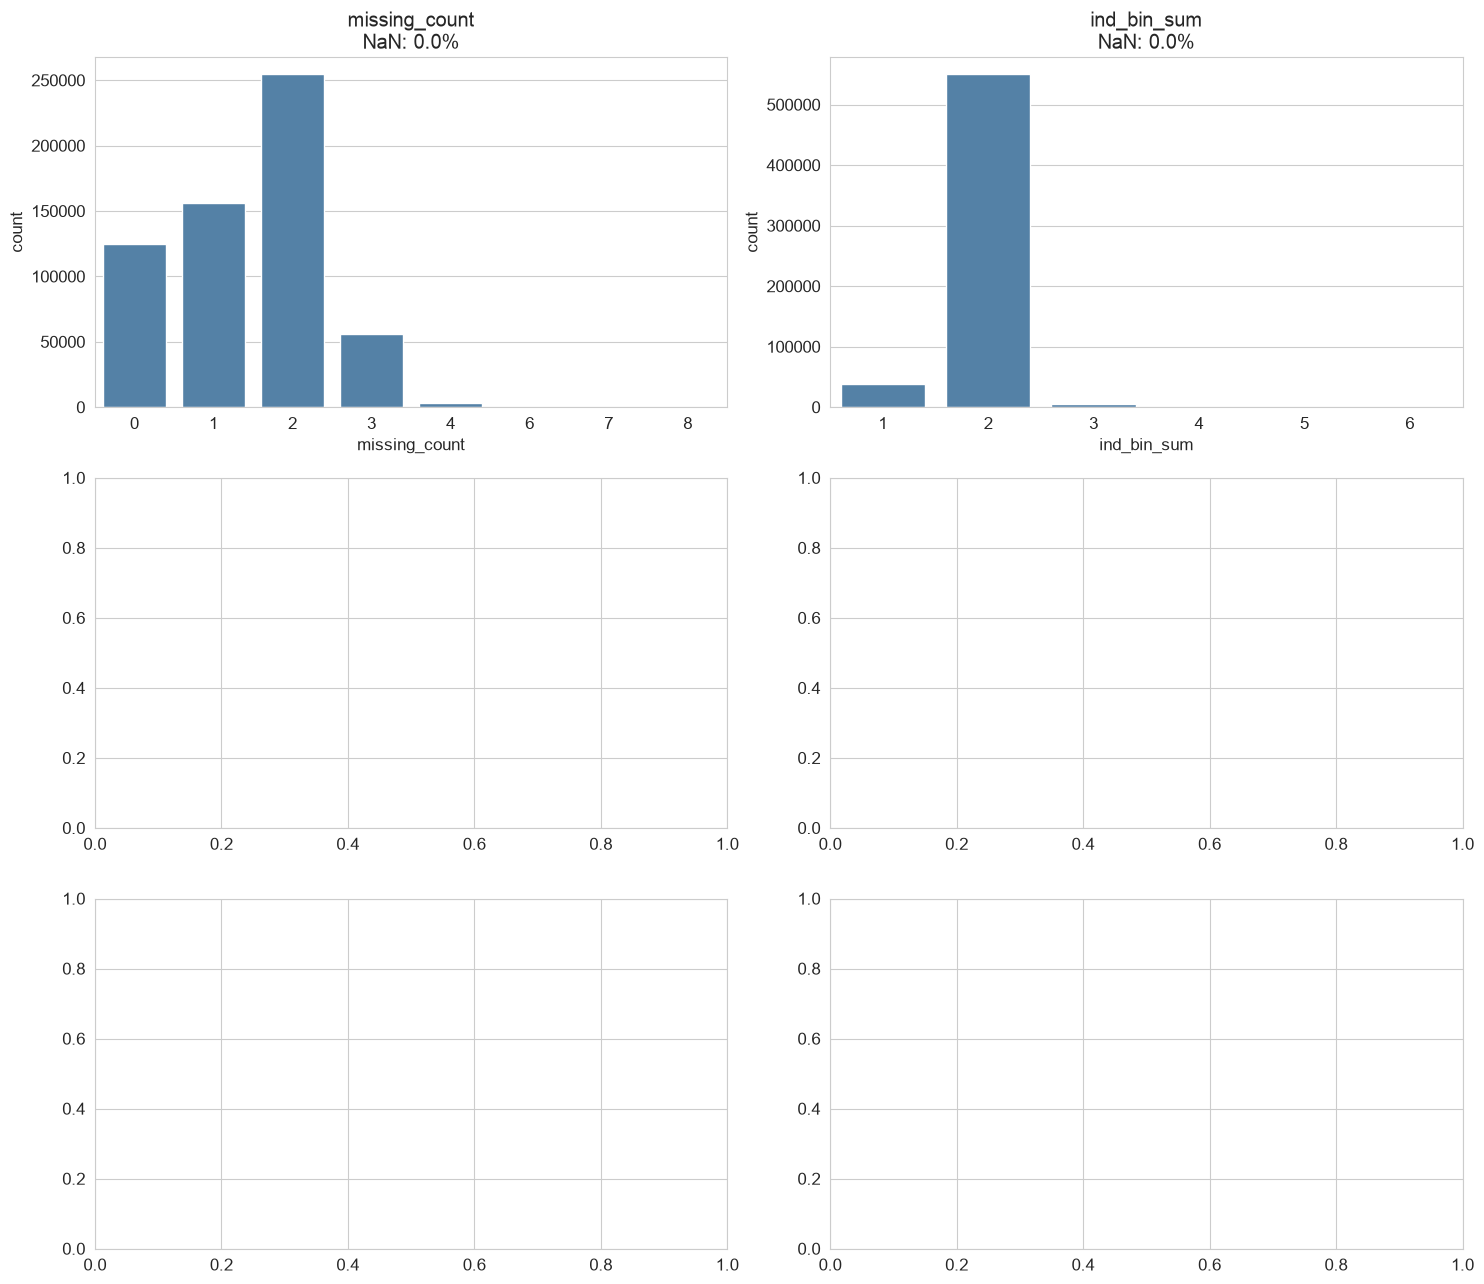

In [19]:
fig, axes = plt.subplots(3, 2, figsize=(15, 13))
axes = axes.ravel()

for ax, col in zip(axes, new_features):
    values = df_tr_cl[col].dropna()

    if col in ("missing_count", "ind_bin_sum"):
        sns.countplot(x=values, ax=ax, color="steelblue")
    else:
        # Обрезаем только диапазон графика: данные в df_tr_cl не меняются.
        lower, upper = values.quantile([0.01, 0.99])
        shown = values.between(lower, upper)

        sns.histplot(
            values[shown],
            bins=50,
            ax=ax,
            color="steelblue",
        )
        ax.set_xlabel(f"{col} (1–99-й перцентили)")

    missing_share = df_tr_cl[col].isna().mean()
    ax.set_title(f"{col}\nNaN: {missing_share:.1%}")

plt.tight_layout()
plt.show()

In [20]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

feature_cols = df_tr_cl.columns.drop("target")
X_df = df_tr_cl[feature_cols]

# Все признаки, в названии которых есть 'cat', считаем категориальными.
categorical_cols = [
    col for col in X_df.columns
    if col.endswith("_cat")
]
numeric_cols = [col for col in X_df.columns if col not in categorical_cols]

X_df = X_df.copy()

X_df[numeric_cols] = X_df[numeric_cols].replace(-1, np.nan)
X_df[categorical_cols] = X_df[categorical_cols].fillna(-1)

y = LabelEncoder().fit_transform(df_tr_cl["target"])
class_names = ["0", "1"]

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_df, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", dtype=np.float32), categorical_cols),
        ("num", numeric_transformer, numeric_cols),
    ],
    remainder="drop",
    sparse_threshold=1.0,
)

X_train = preprocessor.fit_transform(X_train_df).astype(np.float32)
X_test = preprocessor.transform(X_test_df).astype(np.float32)
feature_cols = preprocessor.get_feature_names_out()

scaler = StandardScaler(with_mean=False)
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Категориальные признаки ({len(categorical_cols)}): {categorical_cols}")
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Распределение классов (train): {np.bincount(y_train)}')


Категориальные признаки (14): ['ps_ind_02_cat', 'ps_ind_04_cat', 'ps_ind_05_cat', 'ps_car_01_cat', 'ps_car_02_cat', 'ps_car_03_cat', 'ps_car_04_cat', 'ps_car_05_cat', 'ps_car_06_cat', 'ps_car_07_cat', 'ps_car_08_cat', 'ps_car_09_cat', 'ps_car_10_cat', 'ps_car_11_cat']
Train: (476169, 224), Test: (119043, 224)
Распределение классов (train): [458814  17355]


Соберём предобработку в одну функцию

In [ ]:
def make_features(df, frequency_maps=None):
    #удаление неинформативных признаков
    X = df.drop(
        columns=[
            "id", "target",
            "ps_calc_01", "ps_calc_02", "ps_calc_03",
        ],
        errors="ignore",).copy()

    X = X.loc[:, ~X.columns.str.startswith("ps_calc_")].copy()
    base_cols = X.columns.tolist()

    #создание новых признаков
    categorical_cols = [
        col for col in base_cols if col.endswith("_cat")
    ]
    numeric_cols = [
        col for col in base_cols if col not in categorical_cols
    ]

    ind_cols = [
        col for col in X.columns if col.startswith("ps_ind_")
    ]

    ind_key = pd.util.hash_pandas_object(
        X[ind_cols],
        index=False,
    )

    if frequency_maps is None:
        frequency_maps = {
            col: X[col].value_counts(dropna=False)
            for col in categorical_cols
        }
        frequency_maps["new_ind"] = ind_key.value_counts()

    for col in categorical_cols:
        X[f"{col}_count"] = (
            X[col]
            .map(frequency_maps[col])
            .fillna(0)
            .astype(np.float32)
        )

    X["new_ind_count"] = (
        ind_key
        .map(frequency_maps["new_ind"])
        .fillna(0)
        .to_numpy(dtype=np.float32)
    )

    missing = X[base_cols].eq(-1) | X[base_cols].isna()
    X["missing_count"] = missing.sum(axis=1)

    ind_bin_cols = [
        col for col in base_cols
        if col.startswith("ps_ind_") and col.endswith("_bin")
    ]
    X["ind_bin_sum"] = X[ind_bin_cols].eq(1).sum(axis=1)

    X[numeric_cols] = X[numeric_cols].replace(-1, np.nan)
    X[categorical_cols] = X[categorical_cols].fillna(-1)
    X = X.replace([np.inf, -np.inf], np.nan)

    numeric_cols = [
        col for col in X.columns if col not in categorical_cols
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore",
                    dtype=np.float32,
                ),
                categorical_cols,
            ),
            (
                "num",
                SimpleImputer(strategy="median"),
                numeric_cols,
            ),
        ],
        sparse_threshold=1.0,
    )

    return X, preprocessor, frequency_maps

### Обучения моделей

In [22]:
# Словарь для сбора результатов всех моделей
results = {}

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, scaled=False):
    """Обучить, предсказать, сохранить результаты."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred, average='macro')
    gini = 2 * roc_auc_score(y_te, y_proba) - 1
    results[name] = {'gini': gini, 'accuracy': acc, 'f1_macro': f1}
    print(f'{name}: gini={gini:.4f}, accuracy={acc:.4f}, F1-macro={f1:.4f}')
    return y_pred

 Для начала рассмотрим различные SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import ParameterGrid

np.random.seed(RANDOM_STATE)
rng = np.random.default_rng(RANDOM_STATE)

d_SVM = {}

n_samples = X_train_sc.shape[0]
sample_size = min(10_000, n_samples)
all_indices = np.arange(n_samples)

if sample_size == n_samples:
    idx_sub = all_indices
else:
    idx_sub, _ = train_test_split(
        all_indices,
        train_size=sample_size,
        stratify=y_train,
        random_state=RANDOM_STATE,
    )
    
X_train_sub = X_train_sc[idx_sub]
y_train_sub = y_train[idx_sub]

param_grid = {
    'C': [0.1, 0.01, 0.001, 0.0001],
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
}


best_gini = -np.inf
best_params = None
best_model = None

for params in ParameterGrid(param_grid):

    svm_sigmoid = SVC(
        **params,
        kernel="sigmoid",
        class_weight="balanced",
        random_state=RANDOM_STATE
    )

    svm_sigmoid.fit(X_train_sub, y_train_sub)

    # Оценки модели на тестовой выборке
    y_score = svm_sigmoid.decision_function(X_test_sc)

    roc_auc = roc_auc_score(y_test, y_score)
    gini = 2 * roc_auc - 1

    print(f"{params} -> Gini sigmoid: {gini:.5f}")

    if gini > best_gini:
        best_gini = gini
        best_params = params
        best_model = svm_sigmoid

print("\nЛучшие параметры:", best_params)
print(f"Лучший validation Gini sigmoid: {best_gini:.5f}")

d_SVM["svm sigmoid"] = best_model


{'C': 0.1, 'gamma': 1} -> Gini sigmoid: 0.00000
{'C': 0.1, 'gamma': 0.1} -> Gini sigmoid: 0.00000
{'C': 0.1, 'gamma': 0.01} -> Gini sigmoid: 0.19815
{'C': 0.1, 'gamma': 0.001} -> Gini sigmoid: 0.21136
{'C': 0.1, 'gamma': 0.0001} -> Gini sigmoid: 0.21750
{'C': 0.01, 'gamma': 1} -> Gini sigmoid: 0.00000
{'C': 0.01, 'gamma': 0.1} -> Gini sigmoid: 0.00000
{'C': 0.01, 'gamma': 0.01} -> Gini sigmoid: 0.19815
{'C': 0.01, 'gamma': 0.001} -> Gini sigmoid: 0.21840
{'C': 0.01, 'gamma': 0.0001} -> Gini sigmoid: 0.21750
{'C': 0.001, 'gamma': 1} -> Gini sigmoid: 0.00000
{'C': 0.001, 'gamma': 0.1} -> Gini sigmoid: 0.00000
{'C': 0.001, 'gamma': 0.01} -> Gini sigmoid: 0.19815
{'C': 0.001, 'gamma': 0.001} -> Gini sigmoid: 0.21840
{'C': 0.001, 'gamma': 0.0001} -> Gini sigmoid: 0.21750
{'C': 0.0001, 'gamma': 1} -> Gini sigmoid: 0.00000
{'C': 0.0001, 'gamma': 0.1} -> Gini sigmoid: 0.00000
{'C': 0.0001, 'gamma': 0.01} -> Gini sigmoid: 0.19815
{'C': 0.0001, 'gamma': 0.001} -> Gini sigmoid: 0.21840
{'C': 0.00

In [ ]:
param_grid = {
    'C': [0.1, 0.01, 0.001, 0.0001],
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
}

for deg in [2, 3, 4, 5]:

    best_gini = -np.inf
    best_params = None
    best_model = None

    for params in ParameterGrid(param_grid):

        rbf_svm_poly = SVC(
            **params,
            kernel="poly",
            degree=deg,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )

        rbf_svm_poly.fit(X_train_sub, y_train_sub)

        # Оценки модели на тестовой выборке
        y_score = rbf_svm_poly.decision_function(X_test_sc)

        roc_auc = roc_auc_score(y_test, y_score)
        gini = 2 * roc_auc - 1
        

        print(f"{params} -> Gini poly {deg}: {gini:.5f}")
    
        if gini > best_gini:
            best_gini = gini
            best_params = params
            best_model = rbf_svm_poly
    
    print("\nЛучшие параметры:", best_params)
    print(f"Лучший validation Gini poly {deg}: {best_gini:.5f}")
    
    d_SVM[f"svm poly {deg}"] = best_model


{'C': 0.1, 'gamma': 1} -> Gini poly 2: 0.02323
{'C': 0.1, 'gamma': 0.1} -> Gini poly 2: 0.01580
{'C': 0.1, 'gamma': 0.01} -> Gini poly 2: 0.05303
{'C': 0.1, 'gamma': 0.001} -> Gini poly 2: 0.18625
{'C': 0.1, 'gamma': 0.0001} -> Gini poly 2: 0.21061
{'C': 0.01, 'gamma': 1} -> Gini poly 2: 0.02087
{'C': 0.01, 'gamma': 0.1} -> Gini poly 2: 0.00308
{'C': 0.01, 'gamma': 0.01} -> Gini poly 2: 0.12753
{'C': 0.01, 'gamma': 0.001} -> Gini poly 2: 0.21066
{'C': 0.01, 'gamma': 0.0001} -> Gini poly 2: 0.21074
{'C': 0.001, 'gamma': 1} -> Gini poly 2: 0.01581
{'C': 0.001, 'gamma': 0.1} -> Gini poly 2: 0.05303
{'C': 0.001, 'gamma': 0.01} -> Gini poly 2: 0.18625
{'C': 0.001, 'gamma': 0.001} -> Gini poly 2: 0.21061
{'C': 0.001, 'gamma': 0.0001} -> Gini poly 2: 0.21074
{'C': 0.0001, 'gamma': 1} -> Gini poly 2: 0.00308
{'C': 0.0001, 'gamma': 0.1} -> Gini poly 2: 0.12754
{'C': 0.0001, 'gamma': 0.01} -> Gini poly 2: 0.21066
{'C': 0.0001, 'gamma': 0.001} -> Gini poly 2: 0.21074
{'C': 0.0001, 'gamma': 0.0001

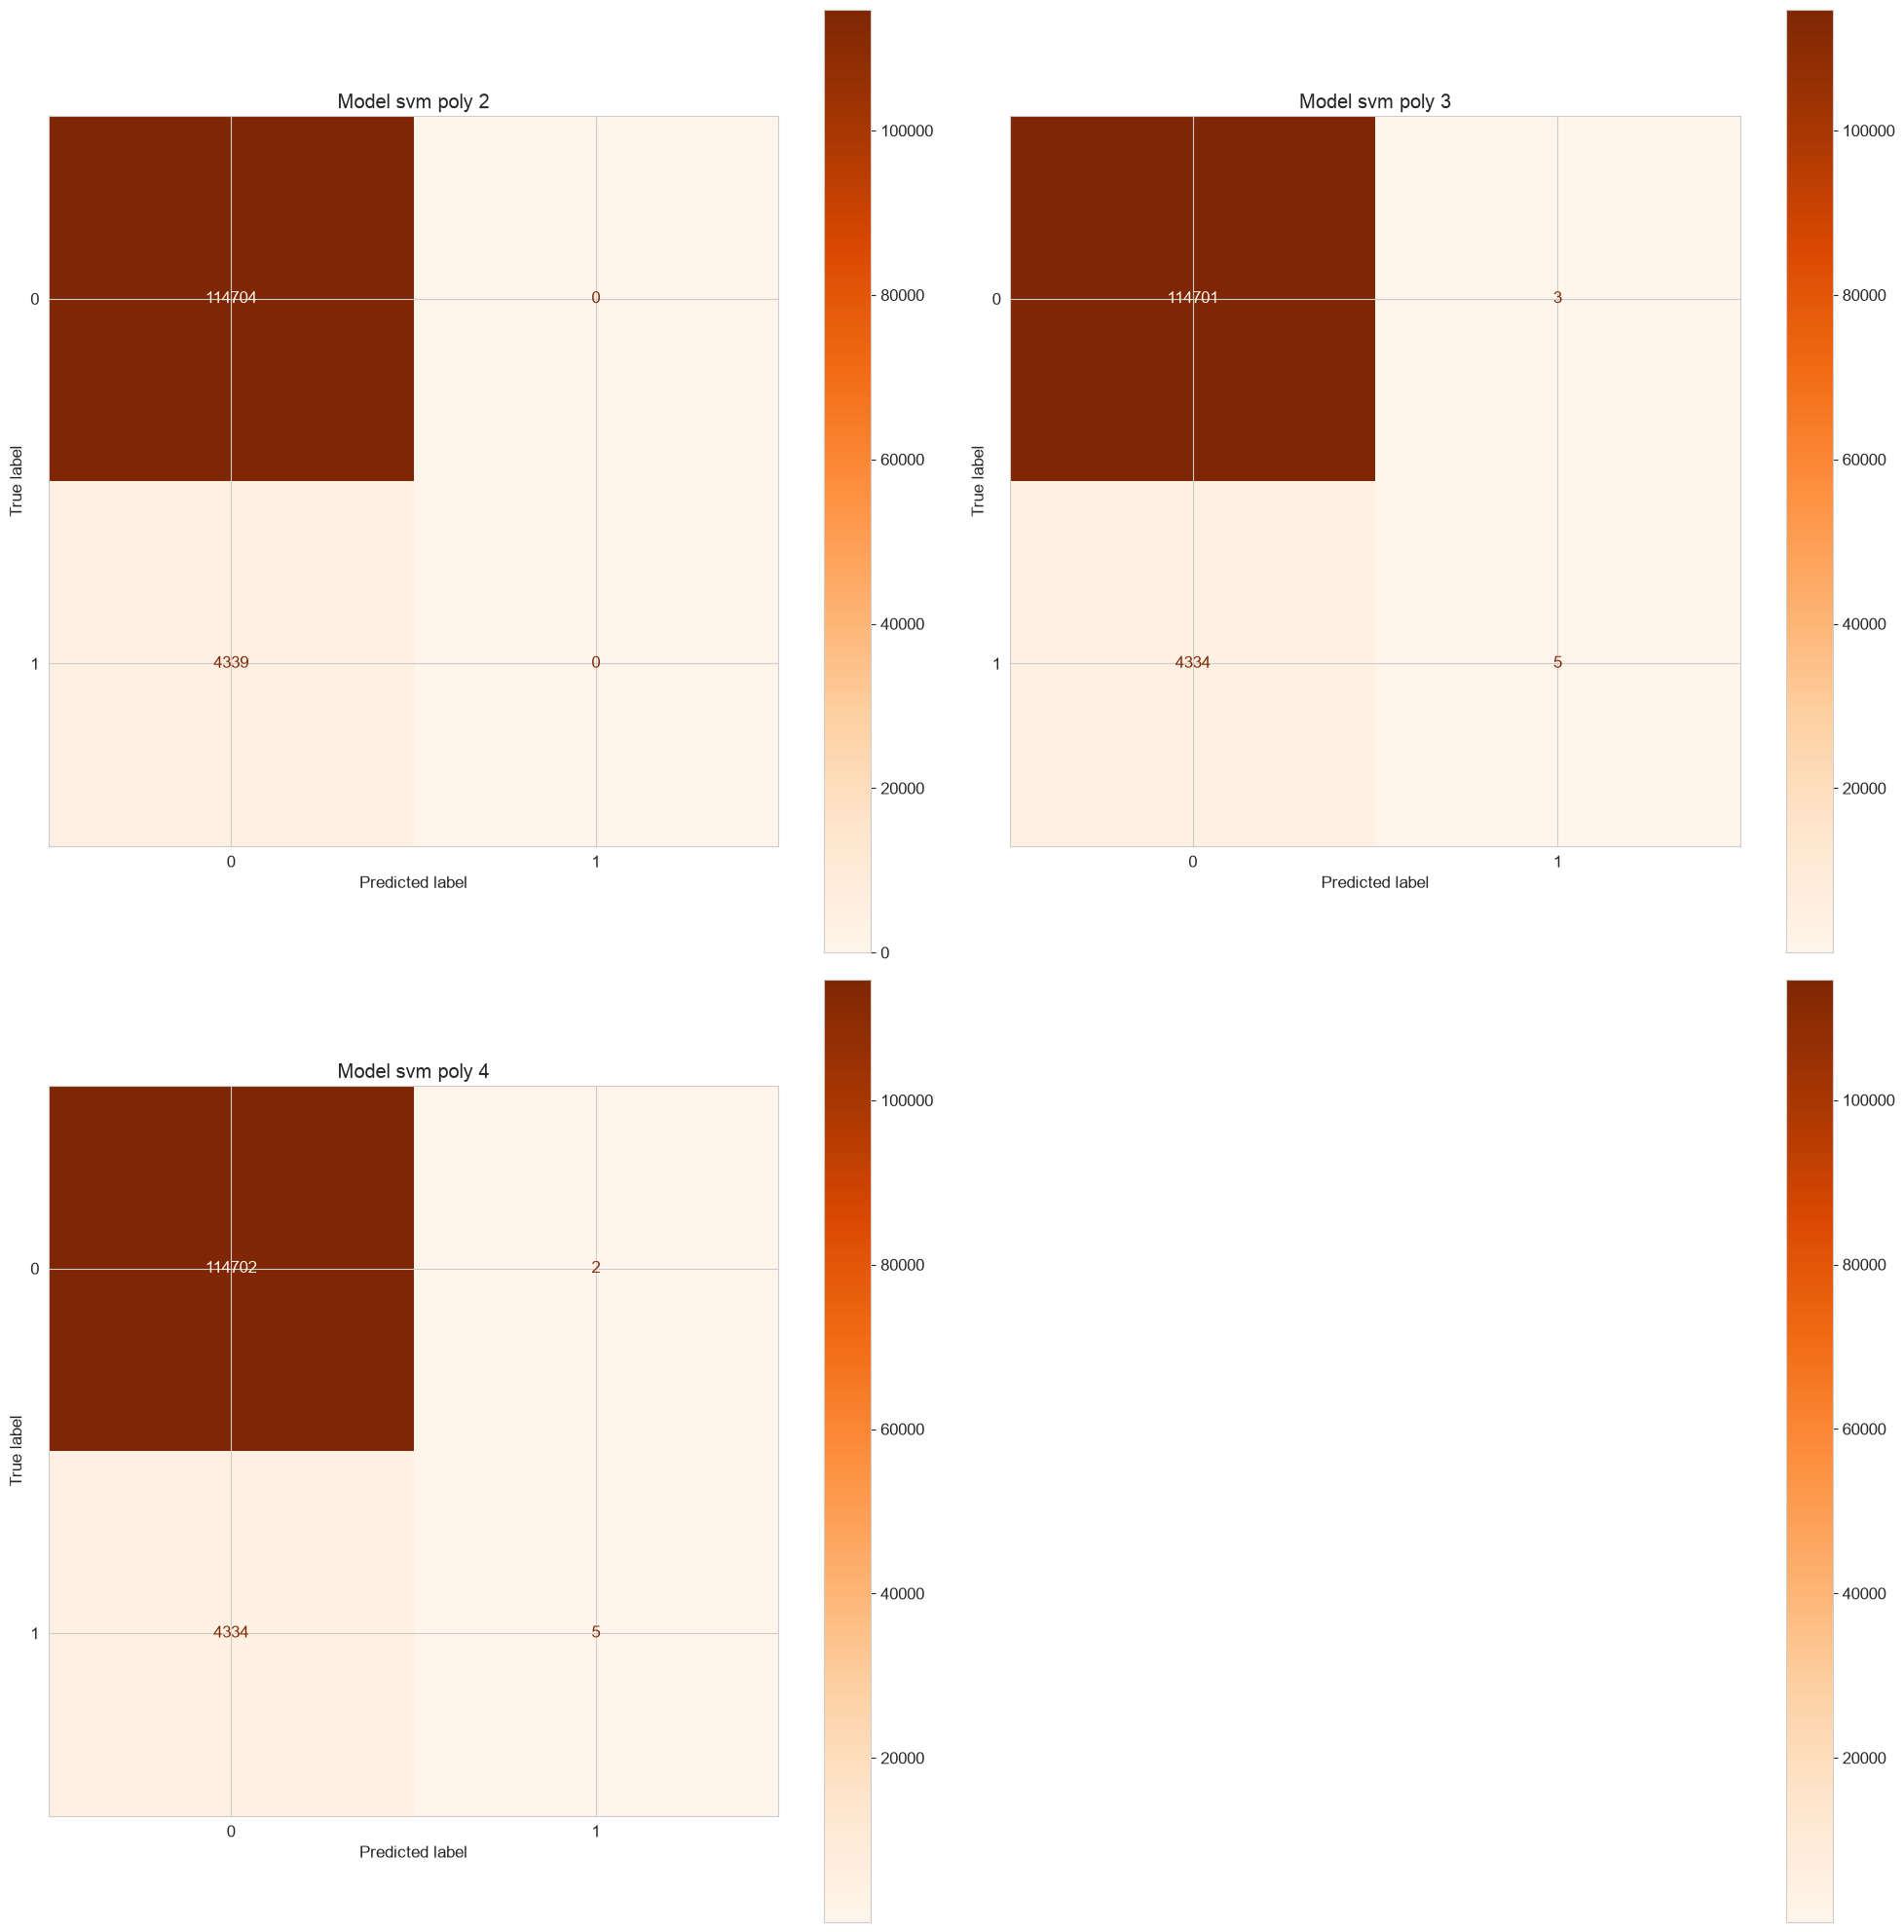

In [ ]:
row = int(np.ceil(len(d_SVM) / 2))
fig, axes = plt.subplots(nrows=row, ncols=2, figsize=(20, 20), squeeze=False)

axes = axes.ravel()
for ax, (name, model) in zip(axes, d_SVM.items()):

    
    y_pred = model.predict(X_test_sc)
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=class_names,
        ax=ax,
        cmap="Oranges"
    )
    ax.set_title(f'Model {name}')

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

Теперь перейдём к рассмотрению деревьев

In [29]:
import time
from lightgbm import LGBMClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier


In [ ]:
# Sklearn GradientBoosting (базовый)
gb_sklearn = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                                         random_state=RANDOM_STATE)
y_pred_gb = evaluate_model('GradientBoosting', gb_sklearn, X_train, X_test, y_train, y_test)

GradientBoosting: gini=0.2724, accuracy=0.9633, F1-macro=0.4934


In [ ]:

for depth in [1, 3, 5]:
    for lr in [1, 0.1, 0.01]:
        for iter in [100, 500, 1000]:
            for alpha in [1, 10, 100]:
                t0 = time.time()
                lgbm = LGBMClassifier(n_estimators=iter, learning_rate=lr, max_depth=depth, reg_alpha=alpha,
                                        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
                y_pred_lgbm = evaluate_model('LightGBM', lgbm, X_train, X_test, y_train, y_test)
                print(f"params: depth = {depth}, learning_rate = {lr},  iterations = {iter}, alpha = {alpha}")
                print(f'  Время: {time.time()-t0:.1f}s')

LightGBM: gini=0.2585, accuracy=0.9636, F1-macro=0.4907
params: depth = 1, learning_rate = 1,  iterations = 100, alpha = 1
  Время: 1.9s
LightGBM: gini=0.2601, accuracy=0.9636, F1-macro=0.4907
params: depth = 1, learning_rate = 1,  iterations = 100, alpha = 10
  Время: 1.7s
LightGBM: gini=0.2475, accuracy=0.9636, F1-macro=0.4907
params: depth = 1, learning_rate = 1,  iterations = 100, alpha = 100
  Время: 1.8s
LightGBM: gini=0.2632, accuracy=0.9635, F1-macro=0.4907
params: depth = 1, learning_rate = 1,  iterations = 500, alpha = 1
  Время: 5.6s
LightGBM: gini=0.2639, accuracy=0.9636, F1-macro=0.4907
params: depth = 1, learning_rate = 1,  iterations = 500, alpha = 10
  Время: 6.1s
LightGBM: gini=0.2476, accuracy=0.9636, F1-macro=0.4907
params: depth = 1, learning_rate = 1,  iterations = 500, alpha = 100
  Время: 5.3s
LightGBM: gini=0.2619, accuracy=0.9636, F1-macro=0.4909
params: depth = 1, learning_rate = 1,  iterations = 1000, alpha = 1
  Время: 10.1s
LightGBM: gini=0.2635, accuracy=0

In [ ]:
t0 = time.time()
lgbm = LGBMClassifier(n_estimators=1000, learning_rate= 0.01, max_depth=5,
                    reg_alpha=10, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
y_pred_lgbm = evaluate_model('LightGBM', lgbm, X_train, X_test, y_train, y_test)

print(f'  Время: {time.time()-t0:.1f}s')

LightGBM: gini=0.2764, accuracy=0.9636, F1-macro=0.4907
  Время: 24.6s


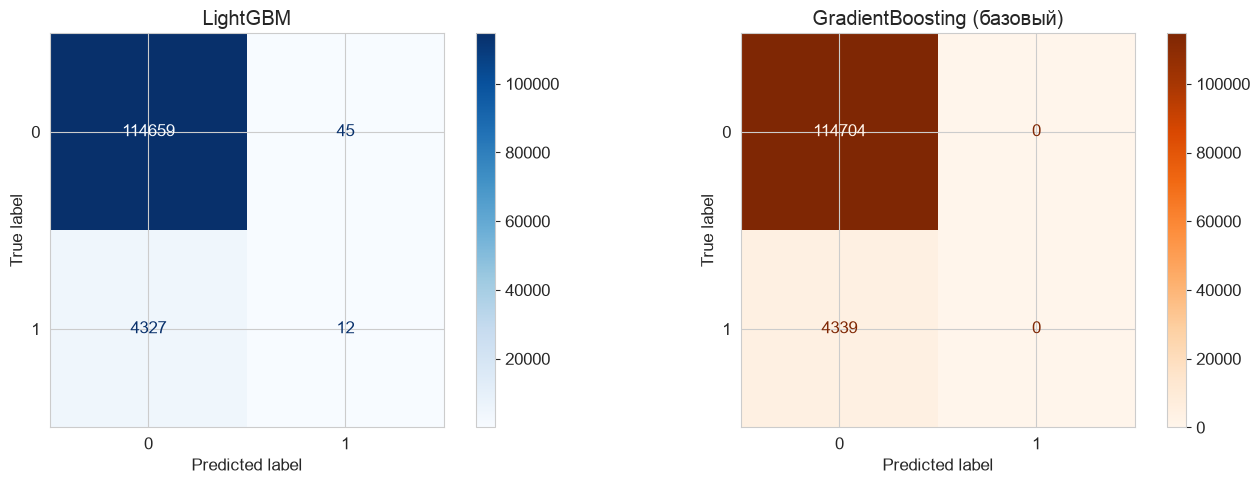

In [ ]:
# Confusion matrix для лучшего SVM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gb, display_labels=class_names, ax=axes[0], cmap='Blues')
axes[0].set_title('LightGBM')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lgbm, display_labels=class_names, ax=axes[1], cmap='Oranges')
axes[1].set_title('GradientBoosting (базовый)')
plt.tight_layout()
plt.show()

In [ ]:

for depth in [1, 3, 5]:
    for lr in [1, 0.1, 0.01]:
        for iter in [100, 500, 1000]:
            for alpha in [1, 10, 100]:
                t0 = time.time()
                xgb = XGBClassifier(n_estimators=iter, learning_rate=lr, max_depth=depth, reg_alpha=alpha,
                                        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
                y_pred_xgb = evaluate_model('XGBoost', xgb, X_train, X_test, y_train, y_test)
                print(f"params: depth = {depth}, learning_rate = {lr},  iterations = {iter}, alpha = {alpha}")
                print(f'  Время: {time.time()-t0:.1f}s')


# t0 = time.time()
# xgb = XGBClassifier(n_estimators=500, learning_rate=0.1, max_depth=3, reg_alpha=10, eval_metric="auc",
#                         random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
# y_pred_xgb = evaluate_model('XGBoost', xgb, X_train, X_test, y_train, y_test)
# print(f'  Время: {time.time()-t0:.1f}s')


XGBoost: gini=0.2623, accuracy=0.9636, F1-macro=0.4907
params: depth = 1, learning_rate = 1,  iterations = 100, alpha = 1
  Время: 2.0s
XGBoost: gini=0.2623, accuracy=0.9636, F1-macro=0.4907
params: depth = 1, learning_rate = 1,  iterations = 100, alpha = 10
  Время: 1.9s
XGBoost: gini=0.2499, accuracy=0.9636, F1-macro=0.4907
params: depth = 1, learning_rate = 1,  iterations = 100, alpha = 100
  Время: 1.8s
XGBoost: gini=0.2625, accuracy=0.9636, F1-macro=0.4909
params: depth = 1, learning_rate = 1,  iterations = 500, alpha = 1
  Время: 6.1s
XGBoost: gini=0.2650, accuracy=0.9636, F1-macro=0.4907
params: depth = 1, learning_rate = 1,  iterations = 500, alpha = 10
  Время: 6.1s
XGBoost: gini=0.2500, accuracy=0.9636, F1-macro=0.4907
params: depth = 1, learning_rate = 1,  iterations = 500, alpha = 100
  Время: 5.8s
XGBoost: gini=0.2611, accuracy=0.9636, F1-macro=0.4912
params: depth = 1, learning_rate = 1,  iterations = 1000, alpha = 1
  Время: 11.6s
XGBoost: gini=0.2648, accuracy=0.9636, F

In [ ]:
for depth in [5, 7, 10]:
    for lr in [1, 0.1, 0.01]:
        for iter in [100, 500, 1000]:
            t0 = time.time()
            cb = CatBoostClassifier(iterations=iter, learning_rate=lr, depth=depth,
                                        random_state=RANDOM_STATE, verbose=0)
            y_pred_cb = evaluate_model('CatBoost', cb, X_train, X_test, y_train, y_test)
            print(f"params: depth = {depth}, learning_rate = {lr},  iterations = {iter}")
            print(f'Время: {time.time()-t0:.1f}s')

# t0 = time.time()
# cb = CatBoostClassifier(iterations=1000, learning_rate=0.01, depth=10, reg_lambda=1,
#                                         random_state=RANDOM_STATE, verbose=0)
# y_pred_cb = evaluate_model('CatBoost', cb, X_train, X_test, y_train, y_test)
# print(f'Время: {time.time()-t0:.1f}s')

CatBoost: gini=0.2369, accuracy=0.9630, F1-macro=0.4935
params: depth = 5, learning_rate = 1,  iterations = 100
Время: 7.3s
CatBoost: gini=0.1426, accuracy=0.9614, F1-macro=0.4955
params: depth = 5, learning_rate = 1,  iterations = 500
Время: 37.2s
CatBoost: gini=0.1029, accuracy=0.9594, F1-macro=0.4992
params: depth = 5, learning_rate = 1,  iterations = 1000
Время: 54.8s
CatBoost: gini=0.2664, accuracy=0.9635, F1-macro=0.4907
params: depth = 5, learning_rate = 0.1,  iterations = 100
Время: 8.4s
CatBoost: gini=0.2774, accuracy=0.9636, F1-macro=0.4921
params: depth = 5, learning_rate = 0.1,  iterations = 500
Время: 36.6s
CatBoost: gini=0.2757, accuracy=0.9635, F1-macro=0.4919
params: depth = 5, learning_rate = 0.1,  iterations = 1000
Время: 55.9s
CatBoost: gini=0.2367, accuracy=0.9636, F1-macro=0.4907
params: depth = 5, learning_rate = 0.01,  iterations = 100
Время: 6.7s
CatBoost: gini=0.2560, accuracy=0.9636, F1-macro=0.4907
params: depth = 5, learning_rate = 0.01,  iterations = 500
Вр

In [ ]:
for depth in [5, 10, 15]:
    for min_sampl in [1, 2, 5]:
        for iter in [100, 500, 1000]:
            rf = RandomForestClassifier(n_estimators=iter, max_depth=depth, min_samples_leaf=min_sampl,
                                        random_state=RANDOM_STATE, n_jobs=-1)
            y_pred_rf = evaluate_model('RandomForest', rf, X_train, X_test, y_train, y_test)
            print(f"params: depth = {depth}, learning_rate = {lr},  iterations = {iter}")

RandomForest: gini=0.2379, accuracy=0.9636, F1-macro=0.4907
params: depth = 5, learning_rate = 0.01,  iterations = 100
RandomForest: gini=0.2397, accuracy=0.9636, F1-macro=0.4907
params: depth = 5, learning_rate = 0.01,  iterations = 500
RandomForest: gini=0.2395, accuracy=0.9636, F1-macro=0.4907
params: depth = 5, learning_rate = 0.01,  iterations = 1000
RandomForest: gini=0.2373, accuracy=0.9636, F1-macro=0.4907
params: depth = 5, learning_rate = 0.01,  iterations = 100
RandomForest: gini=0.2393, accuracy=0.9636, F1-macro=0.4907
params: depth = 5, learning_rate = 0.01,  iterations = 500
RandomForest: gini=0.2390, accuracy=0.9636, F1-macro=0.4907
params: depth = 5, learning_rate = 0.01,  iterations = 1000
RandomForest: gini=0.2369, accuracy=0.9636, F1-macro=0.4907
params: depth = 5, learning_rate = 0.01,  iterations = 100
RandomForest: gini=0.2394, accuracy=0.9636, F1-macro=0.4907
params: depth = 5, learning_rate = 0.01,  iterations = 500
RandomForest: gini=0.2391, accuracy=0.9636, F1

Модели SVM, RandomForestClassifier и GradientBoostingClassifier выполняются слишком долго и в дальнейшем не проявили себя в стекинге и блендинге, так что в финальную версию они не вошли

## Стекинг и блендинг

In [47]:
# === Блендинг вручную ===
from sklearn.linear_model import LogisticRegression

# Делим train на 2 части
X_blend_train, X_blend_val, y_blend_train, y_blend_val = train_test_split(
    X_train_sc, y_train, test_size=0.3, random_state=RANDOM_STATE, stratify=y_train)

# Базовые модели
base_models = [
    ('xgboost', XGBClassifier(
        n_estimators=500, learning_rate=0.1, max_depth=3,
        random_state=RANDOM_STATE, reg_alpha=10,
        eval_metric='logloss', n_jobs=-1, verbosity=0,
    )),
    ('lgbm_5', LGBMClassifier(
        n_estimators=500, learning_rate=0.1, max_depth=3,
        reg_alpha=10, random_state=RANDOM_STATE,
        n_jobs=-1, verbosity=-1,
    )),
    ('cat', CatBoostClassifier(
        iterations=1000, learning_rate=0.01, depth=10,
        random_state=RANDOM_STATE, verbose=0,
    )),
]  

# Обучаем на 70% train, предсказываем на 30% (blend_val) и на test
meta_train = np.zeros(
    (X_blend_val.shape[0], len(base_models))
)
meta_test = np.zeros(
    (X_test_sc.shape[0], len(base_models))
)

for i, (name, model) in enumerate(base_models):
    model.fit(X_blend_train, y_blend_train)
    val_pred = model.predict(X_blend_val)
    if hasattr(model, 'predict_proba'):
        val_score = model.predict_proba(X_blend_val)[:, 1]
        test_score = model.predict_proba(X_test_sc)[:, 1]
    else:
        val_score = model.decision_function(X_blend_val)
        test_score = model.decision_function(X_test_sc)
    meta_train[:, i] = val_score
    meta_test[:, i] = test_score
    gini = 2 * roc_auc_score(y_test, test_score) - 1
    print(f'  {name}: gini={gini:.4f}')
    print(f'  {name}: val_acc={accuracy_score(y_blend_val, val_pred):.4f}')

# Мета-модель
meta_clf = LogisticRegression(random_state=RANDOM_STATE, max_iter=500)
meta_clf.fit(meta_train, y_blend_val)
y_pred_blend = meta_clf.predict(meta_test)
y_score_blend = meta_clf.predict_proba(meta_test)[:, 1]

results['Blending'] = {
    'gini': 2 * roc_auc_score(y_test, y_score_blend) - 1,
    'accuracy': accuracy_score(y_test, y_pred_blend),
    'f1_macro': f1_score(y_test, y_pred_blend, average='macro')
}
print(f"\nBlending: gini={results['Blending']['gini']:.4f}, "
      f"accuracy={results['Blending']['accuracy']:.4f}, "
      f"F1-macro={results['Blending']['f1_macro']:.4f}")

  xgboost: gini=0.2801
  xgboost: val_acc=0.9635
  lgbm_5: gini=0.2786
  lgbm_5: val_acc=0.9635
  cat: gini=0.2738
  cat: val_acc=0.9636

Blending: gini=0.2816, accuracy=0.9636, F1-macro=0.4935


In [31]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Разделяем исходные данные до расчёта частот.
train_part, valid_part = train_test_split(
    df_train,
    test_size=0.2,
    stratify=df_train["target"],
    random_state=RANDOM_STATE,
)

X_train_df, local_preprocessor, frequency_maps = make_features(
    train_part
)

X_valid_df, _, _ = make_features(
    valid_part,
    frequency_maps=frequency_maps,
)

y_train = train_part["target"].to_numpy()
y_valid = valid_part["target"].to_numpy()


def model_pipeline(model):
    return Pipeline([
        ("preprocessor", clone(local_preprocessor)),
        ("model", model),
    ])


local_stacking = StackingClassifier(
    estimators=[
        (
            "lgbm",  model_pipeline(LGBMClassifier(n_estimators=500, learning_rate= 0.1, max_depth=3,
                            reg_alpha=10, n_jobs=-1, verbose=-1)),
        ),
        (
            "cat",  model_pipeline(CatBoostClassifier(iterations=500, learning_rate = 0.1, depth=5, verbose=0)),
        ),
        (
            'xgboost',model_pipeline(XGBClassifier(n_estimators=500, learning_rate=0.1, max_depth=3,
                         reg_alpha=10, eval_metric='mlogloss', n_jobs=-1, verbosity=0))
        )
    ],
    final_estimator=LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=500,
    ),
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE,
    ),
    stack_method="predict_proba",
    n_jobs=1,
)

t0 = time.time()

y_pred_stack = evaluate_model(
    "Stacking",
    local_stacking,
    X_train_df,
    X_valid_df,
    y_train,
    y_valid,
)

print(f"Время: {time.time() - t0:.1f}s")
print(f"Gini: {results['Stacking']['gini']:.4f}")
print(
    classification_report(
        y_valid,
        y_pred_stack,
        target_names=class_names,
    )
)

Stacking: gini=0.2835, accuracy=0.9635, F1-macro=0.4935
Время: 200.1s
Gini: 0.2835
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114704
           1       0.43      0.00      0.01      4339

    accuracy                           0.96    119043
   macro avg       0.70      0.50      0.49    119043
weighted avg       0.94      0.96      0.95    119043



## Обучение stacking на полном train и прогноз для test

In [ ]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold

train_full = pd.read_csv("porto-seguro-safe-driver-prediction/train.csv")
test_kaggle = pd.read_csv("porto-seguro-safe-driver-prediction/test.csv")


X_full, preprocessor, frequency_maps_full = make_features(
    train_full
)

X_test_kaggle, _, _ = make_features(
    test_kaggle,
    frequency_maps=frequency_maps_full,
)

y_full = train_full["target"].astype(np.int8)

assert X_full.columns.equals(X_test_kaggle.columns)

final_stacking = clone(local_stacking)

final_stacking.set_params(
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE,
    ),
    stack_method="predict_proba",
    passthrough=False,
    n_jobs=1,
)

final_stacking.fit(X_full, y_full)



test_probability = final_stacking.predict_proba(
    X_test_kaggle
)[:, 1]

assert np.isfinite(test_probability).all()

submission = pd.DataFrame({
    "id": test_kaggle["id"].to_numpy(),
    "target": test_probability,
})

submission.to_csv("submission.csv", index=False)
display(submission.head())

,id,target
0,0,0.028827
1,1,0.028729
2,2,0.027231
3,3,0.023528
4,4,0.032962


## Подтверждение результатов соревнования

Мои последние результаты

In [49]:
import subprocess
import pandas as pd
from io import StringIO

result = subprocess.run(
    [
        "kaggle",
        "competitions",
        "submissions",
        "-c",
        "porto-seguro-safe-driver-prediction",
        "--csv"
    ],
    capture_output=True,
    text=True
)

df_submissions = pd.read_csv(StringIO(result.stdout))

df_submissions.head(3)

,ref,fileName,date,description,status,publicScore,privateScore
0,56736328,submission.csv,2026-10-01 00:23:35.597000,NaN,SubmissionStatus.COMPLETE,0.28504,0.28996
1,56722726,submission.csv,2026-10-01 00:02:55.480000,NaN,SubmissionStatus.COMPLETE,0.28504,0.28996
2,56721819,submission.csv,2026-09-30 23:42:24.407000,NaN,SubmissionStatus.COMPLETE,0.28388,0.28813


Результаты метрик для 5%, 10%, 20% и 25% лучших участников

In [79]:
import pandas as pd
from pathlib import Path
import math

# Находим CSV с leaderboard
df = pd.read_csv("porto-seguro-safe-driver-prediction-privateleaderboard-2026-10-01T08-20-04.csv")
n = len(df)
percentiles = {
    "Top 5%": math.ceil(n * 0.05),
    "Top 10%": math.ceil(n * 0.10),
    "Top 20%": math.ceil(n * 0.20),
    "Top 25%": math.ceil(n * 0.25),
}

rows = []

for name, position in percentiles.items():
    row = df.iloc[position - 1]

    rows.append({
        "Percentile": name,
        "Rank": position,
        "Privet Score": row["Score"]
    })

result = pd.DataFrame(rows)

result

,Percentile,Rank,Privet Score
0,Top 5%,258,0.29023
1,Top 10%,516,0.28995
2,Top 20%,1032,0.28986
3,Top 25%,1290,0.28956


![Результат на Kaggle](Screenshot_result.png)